<a href="https://colab.research.google.com/github/ahmadshajhan/Ahmad/blob/main/Pytorch_Cooking_show.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision

import matplotlib.pyplot as plt
import numpy as np


##1. Getting a dataset

In [ ]:
from torchvision import datasets

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None,
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None,
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.9MB/s]


In [ ]:
# Seee the first traning example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_t_idx= train_data.class_to_idx
class_t_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
image.shape

torch.Size([1, 28, 28])

Image shape: torch.Size([1, 28, 28])


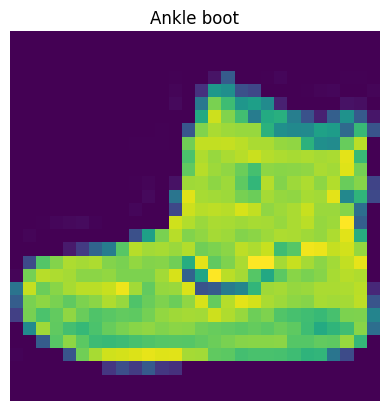

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]

print(f"Image shape: {image.shape}")

plt.imshow(image.squeeze())
plt.title(class_name[label])
plt.axis("off");

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

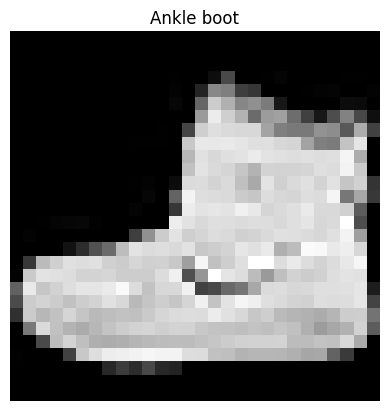

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_name[label])
plt.axis(False)

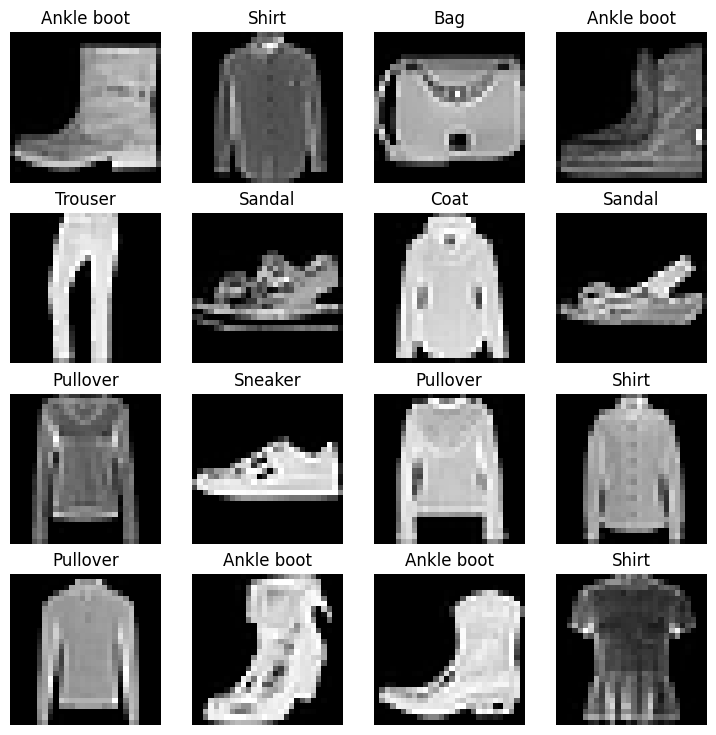

In [ ]:
#Plot more image
torch.manual_seed(42)

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap="gray")
  plt.axis(False)
  plt.title(class_name[label])

### Preparing DataLoader

In [ ]:
from torch.utils.data import DataLoader

#Setup the batch size hyperparameter

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [ ]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c496ca9ff20>,
 <torch.utils.data.dataloader.DataLoader at 0x7c496cb5d190>)

In [ ]:
#Let's Check out what we created
print(f"Dataloader: {train_dataloader}\nLength: {len(train_dataloader)}\nType: {type(train_dataloader)}")
print(f"Dataloader: {test_dataloader}\nLength: {len(test_dataloader)}\nType: {type(test_dataloader)}")

Dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7c496ca9ff20>
Length: 1875
Type: <class 'torch.utils.data.dataloader.DataLoader'>
Dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7c496cb5d190>
Length: 313
Type: <class 'torch.utils.data.dataloader.DataLoader'>


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 8, Class Name: Bag


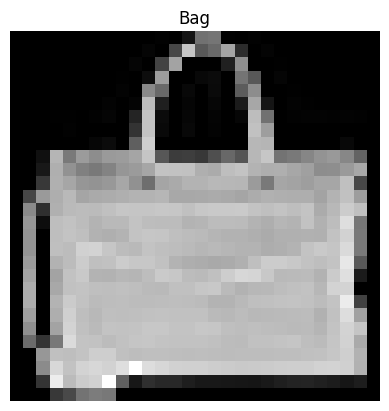

In [ ]:
#torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=(1,)).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.axis(False)
plt.title(class_name[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label}, Class Name: {class_name[label]}")

## 3. Model 0: Build a baseline model

In [ ]:
flatten_model = nn.Flatten()

#Get a single model

x = train_features_batch[0]
output = flatten_model(x)
print(f"Shape before flatten: {x.shape}\nShape after flatten: {output.shape}")
print(f"Number of parameters in flatten layer: {sum(p.numel() for p in flatten_model.parameters())}")

Shape before flatten: torch.Size([1, 28, 28])
Shape after flatten: torch.Size([1, 784])
Number of parameters in flatten layer: 0


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
             input_shape: int,
             hidden_units: int,
             output_shape: int):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units,
                  ),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape,
                  )
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
import torch
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(
    input_shape=784, #this is 28*28
    hidden_units=10,
    output_shape=len(class_name)
).to("cpu")

In [ ]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

###3.1 Setup loss otimizer and evaluation matrix

In [ ]:
import requests
from pathlib import Path
#DOWNLOAD HELEPER FUNCTION FORM PYTORCH REPO
if Path("heleper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("heleper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
#Import accuracy function
from heleper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

#### 3.2 Creating a function to time our experiment

In [ ]:
from timeit import default_timer as Timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Printv difference between start and end time"""
  total_time = end - start

  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time


In [ ]:
start_time = Timer()

#Some code

end_time  = Timer()
print(f"Total time: {print_train_time(start=start_time, end=end_time, device="cpu")}")

Train time on cpu: 0.000 seconds
Total time: 4.798300005859346e-05


### 3.3 Creating a traning loop and traning a model on batch of data

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = Timer()

epochs = 3

#Creating a traning and test loop
for epoch in tqdm(range(epochs)):
  print(f"[INFO] Epoch: {epoch}\n----")

  train_loss = 0
  #Adda loop to loop through the traning batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    #1. Forward pass
    y_pred = model_0(X)

    #2. Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss backward
    loss.backward()

    #5. Optimizer step
    optimizer.step()

    #Prin out what's happening

    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader)} samples")
  # Devide total train loss by length of trin dataloader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_dataloader:

      test_pred = model_0(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_pred.argmax(dim=1))
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    #Print out what's happining
    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")
    print(f"Epoch: {epoch} | Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

#Calculate the traning time
train_time_end_on_cpu = Timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                        end=train_time_end_on_cpu,
                                        device="cpu")

  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Epoch: 0
----
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples
Looked at 51200/1875 samples
Train loss: 0.59039 | Test loss: 0.50954 | Test acc: 82.04%
Epoch: 0 | Train loss: 0.59039 | Test loss: 0.50954 | Test acc: 82.04%
[INFO] Epoch: 1
----
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples
Looked at 51200/1875 samples
Train loss: 0.47633 | Test loss: 0.47989 | Test acc: 83.20%
Epoch: 1 | Train loss: 0.47633 | Test loss: 0.47989 | Test acc: 83.20%
[INFO] Epoch: 2
----
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples
Looked at 51200/1875 samples
Train loss: 0.45503 | Test loss: 0.47664 | Test acc: 83.43%
Epoch: 2 | Train loss: 0.45503 | Test loss: 0.47664 | Test acc: 83.43%
Train time on cpu: 26.540 seconds


### Make Predictions and get model0 results

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device): # Added device parameter
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      # Move data to the target device
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      #Accumulate the loss and acc velues per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

#Calculate the model 0 results on test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device="cpu") # Model 0 was on CPU

## 5. Setup device agnostic code

In [ ]:
!nvidia-smi

Sun Jul  5 22:08:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
torch.cuda.is_available()

True

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

##6. Modle 1: Building a better model with non-linerity

# Create a model with non-liner and lianer layer

In [ ]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hodden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hodden_units),
        nn.ReLU(),
        nn.Linear(in_features=hodden_units,
                  out_features=output_shape),
        nn.ReLU()
    )
  def forward(self, x: torch.tensor):
    return self.layer_stack(x)

In [ ]:
#Create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(
    input_shape=784,
    hodden_units=10,
    output_shape=len(class_name)
).to(device)

In [ ]:
from heleper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

### 6.2 Functionizing traning and evaluation/testing loop

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
  train_loss, train_acc = 0, 0
  model.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1)) # go from logits -> prediction labels
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")


In [ ]:
torch.manual_seed(42)

from timeit import default_timer as Timer
train_time_start_on_cpu = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"[INFO] Epoch: {epoch}\n----")
  train_step(model=model_1,
           data_loader=train_dataloader,
           loss_fn=loss_fn,
           optimizer=optimizer,
           accuracy_fn=accuracy_fn,
           device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)
train_time_end_on_cpu = Timer()

  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Epoch: 0
----
Train loss: 1.09199 | Train acc: 61.34%
Test loss: 0.95636 | Test acc: 65.00%
[INFO] Epoch: 1
----
Train loss: 0.78101 | Train acc: 71.93%
Test loss: 0.72227 | Test acc: 73.91%
[INFO] Epoch: 2
----
Train loss: 0.67027 | Train acc: 75.94%
Test loss: 0.68500 | Test acc: 75.02%


In [ ]:
device

'cuda'

In [ ]:
total_train_time = print_train_time(start=train_time_start_on_cpu,
                                  end=train_time_end_on_cpu,
                                  device=device)
print(f"Total training time MODEL_1: {total_train_time:.3f} seconds")
print(f"Total traning time MODEL_0: {total_train_time_model_0:.3f} seconds")

Train time on cuda: 43.095 seconds
Total training time MODEL_1: 43.095 seconds
Total traning time MODEL_0: 26.540 seconds


In [ ]:
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device="cpu")

In [ ]:
from torch.autograd import forward_ad
# Create a Convolutional neural network
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.cove_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=(3, 3),
                  stride = 1,
                  padding=1) ,#Values we can set ourself in our NN's are clled hyperparameters
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=(3, 3),
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2, 2))

    )
    self.cove_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=(3, 3),
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=(3, 3), # Fixed: Added missing kernel_size
                  stride=1, # Fixed: Changed stride from (3,3) to 1 for consistent behavior
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2, 2))
    )
    self.classifire = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * 7 * 7, # Fixed: Calculated based on previous layers' output
                  out_features=output_shape,
                  )
    )
  def forward(self, x):
    x = self.cove_block_1(x)
    # print(x.shape) # Removed for cleaner model definition
    x = self.cove_block_2(x)
    # print(x.shape) # Removed for cleaner model definition
    x = self.classifire(x)
    return x

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                            hidden_units=10,
                            output_shape=len(class_name)).to(device)

In [ ]:
rand_image = torch.rand(size=(1, 1, 28, 28)).to(device)
model_2(rand_image)

tensor([[ 0.0372, -0.0748,  0.0573, -0.0396, -0.0098,  0.0194, -0.0003, -0.0114,
          0.0206,  0.0003]], device='cuda:0', grad_fn=<AddmmBackward0>)

###7.1 Stepping Through nn.Conv2d()

In [ ]:
torch.manual_seed(42)
#Create a batch of images
images = torch.randn(size=(32, 3, 64, 64)).to(device)
images.shape

torch.Size([32, 3, 64, 64])

In [ ]:
test_image = images[0]
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0).to(device) # Move the layer to the same device as the input
#pass the data to the cov2d layer
conv_output = conv_layer(test_image.unsqueeze(dim=0))
conv_output.shape

torch.Size([1, 10, 62, 62])

### 7.3 Setup a loss function optimizer for `model_2`

In [ ]:
from heleper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

In [ ]:
model_2.state_dict()

OrderedDict([('cove_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

### 7.4 Traning and testing `model_2` using out traning and testing function

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"[INFO] Epoch: {epoch}\n----")
  train_step(model=model_2,
           data_loader=train_dataloader,
           loss_fn=loss_fn,
           optimizer=optimizer,
           accuracy_fn=accuracy_fn,
           device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)
train_time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                  end=train_time_end_model_2,
                                  device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Epoch: 0
----
Train loss: 0.59593 | Train acc: 78.34%
Test loss: 0.39546 | Test acc: 85.86%
[INFO] Epoch: 1
----
Train loss: 0.36207 | Train acc: 86.84%


In [ ]:
model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_2_results

In [ ]:
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

In [ ]:
# Add training time to result comparison
compare_results["training_time"] = [f"{total_train_time_model_0:.3f}", f"{total_train_time:.3f}", f"{total_train_time_model_2:.3f}"]
compare_results

###8. Compare model results and traninfg time

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_2_results])
compare_results

In [ ]:
# Add traning time to result comaprison
compare_results["training_time"] = [f"{total_train_time_model_0:.3f}", f"{total_train_time_model_2:.3f}"]
compare_results

In [ ]:
compare_results.set_index("model_name")["model_acc"].plot.barh(title="Model accuracy comparison")
plt.xlabel("accuracy (%)")
plt.ylabel("Model")

##9. Make and Evaluate random Predictions with best model

In [ ]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #Prepare thesample
      sample = torch.unsqueeze(sample, dim=0).to(device)

      #Forward pass (model outputs raw logits)
      pred_logits = model(sample)

      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_label = torch.argmax(pred_prob)
      pred.append(pred_label.cpu()) # Changed .numpy() to keep it as a tensor
  return torch.stack(pred)

In [ ]:
import random

test_sample = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_sample.append(sample)
  test_labels.append(label)


test_sample[0].shape

In [ ]:
plt.imshow(test_sample[0].squeeze(), cmap="gray")
plt.title(class_name[test_labels[0]])

In [ ]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_sample)

#Vew first two pedictions
pred_probs[:2]

In [ ]:
pred_classes = pred_probs
pred_classes

tensor([9, 3, 8, 6, 9, 8, 9, 9, 6])

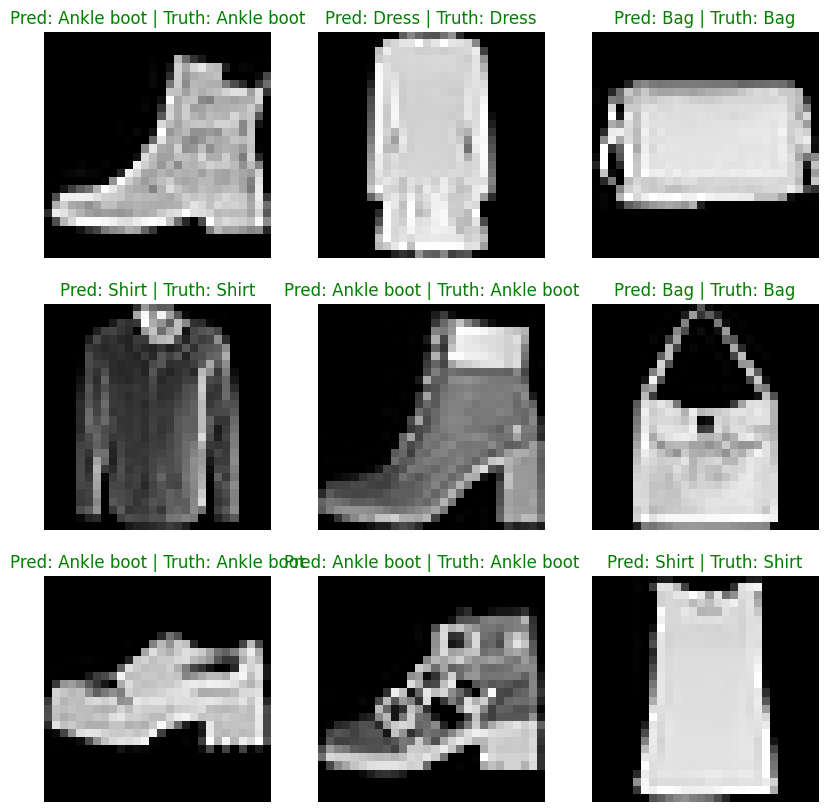

In [ ]:
plt.figure(figsize=(10, 10))
for i, sample in enumerate(test_sample):
  plt.subplot(3, 3, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = class_name[pred_classes[i]]
  truth_label = class_name[test_labels[i]]

  plt.title(f"Pred: {pred_label} | Truth: {truth_label}")

  #Check for equality between pred and cghange color of title text

  if pred_label == truth_label:
    color = "green"
  else:
    color = "red"
  plt.title(f"Pred: {pred_label} | Truth: {truth_label}", color=color)
  plt.axis(False)



## 10 .Making a Confusion Matrix for future prediction evaluation

In [ ]:
from tqdm.auto import tqdm

#1. Make prediction with trained model

y_pred = []
y_true = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader):
    X, y = X.to(device), y.to(device)
    test_pred = model_2(X)
    y_pred.extend(test_pred.argmax(dim=1).cpu().numpy())
    y_true.extend(y.cpu().numpy())

# Concatenate list of prediction into a tensor
print(len(y_pred), len(y_true))
y_pred = torch.tensor(y_pred)
y_true = torch.tensor(y_true)
y_pred[:10], y_true[:10]

  0%|          | 0/313 [00:00<?, ?it/s]

10000 10000


(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]),
 tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]))

In [ ]:
try:
  import torchmetrics, mlxtend
  print(f"mlextend version: {mlxtend.__version__}")
  print(f"torchmetrics version: {torchmetrics.__version__}")
except:
  !pip install torchmetrics mlxtend
  import torchmetrics, mlxtend
  print(f"mlextend version: {mlxtend.__version__}")
  print(f"torchmetrics version: {torchmetrics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.1 MB/s eta 0:00:00
mlextend version: 0.23.4
torchmetrics version: 1.9.0


In [ ]:
y_pred_tensor = y_pred
y_true_tensor = y_true

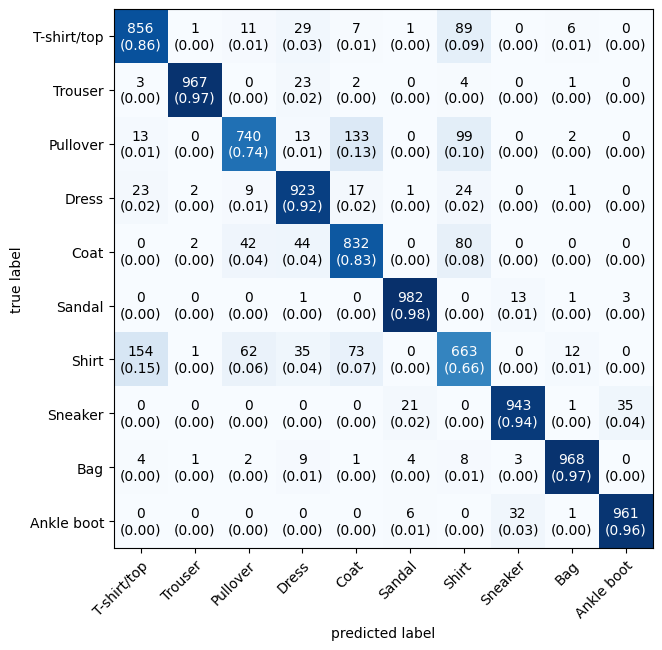

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_name))
confmat_tensor = confmat(preds=y_pred, target=test_data.targets)

#3. Plot our Confusiion Matrix
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                                show_normed=True,
                                figsize=(10, 7),
                                class_names=class_name)

## 11. Save and load best performing model

In [ ]:
from pathlib import Path
#Create model directory Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#Create model save path
MODEL_NAME = "fashion_mnist_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state_dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/fashion_mnist_model_2.pth


In [ ]:
#Create new instance
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                 hidden_units=10,
                                 output_shape=len(class_name)).to(device)

#load in the save state_dict()
loaded_model_2.load_state_dict(torch.load(MODEL_SAVE_PATH))

#Sen the model to target device
loaded_model_2.to(device)

FashionMNISTModelV2(
  (cove_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (cove_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (classifire): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3242024779319763,
 'model_acc': 88.35862619808307}

In [ ]:
#Evaluate loaded model
torch.manual_seed(42)
loaded_model_2 = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
loaded_model_2


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3242024779319763,
 'model_acc': 88.35862619808307}

In [ ]:
torch.isclose(torch.tensor(model_2_results["model_acc"]), torch.tensor(loaded_model_2["model_acc"]),
              atol=1e-02)

tensor(True)